**Step 1: Import Required Libraries**

In [1]:
# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for displaying images and plotting graphs
import matplotlib.pyplot as plt

# Import PyTorch for building and training the neural network
import torch

# Import neural network modules from PyTorch
import torch.nn as nn

# Import optimization algorithms such as Adam
import torch.optim as optim

# Import DataLoader for loading data in batches
from torch.utils.data import DataLoader

# Import MNIST dataset and image transformation utilities
from torchvision import datasets, transforms

**Step 2: Select the Computing Device**

In [2]:
# Check whether a CUDA-enabled GPU is available
# If GPU is available, the model will run on GPU
# Otherwise, the model will run on CPU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Selected device:", device)

Selected device: cpu


**Step 3: Load and Preprocess the MNIST Dataset**

In [3]:
# Convert the images into PyTorch tensors
# ToTensor() also scales pixel values from 0-255 to the range 0-1

transform = transforms.ToTensor()

In [4]:
# Load the training dataset
train_dataset = datasets.MNIST(
    root="data",              # Folder where the dataset will be stored
    train=True,               # Load training images
    download=True,            # Download the dataset if it is not available
    transform=transform       # Apply the defined transformation
)

# Load the testing dataset
test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# Display the number of images
print("Number of training images:", len(train_dataset))
print("Number of testing images:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.78MB/s]

Number of training images: 60000
Number of testing images: 10000


**Step 4: Create DataLoaders**

In [5]:
# Define the number of images processed at one time
batch_size = 128

# Create DataLoader for training data
# shuffle=True randomly changes the order of training images
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# Create DataLoader for testing data
# shuffle=False keeps the testing order unchanged
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training DataLoader created successfully.")
print("Testing DataLoader created successfully.")

Training DataLoader created successfully.
Testing DataLoader created successfully.


**Step 5: Display Original Clean Images**

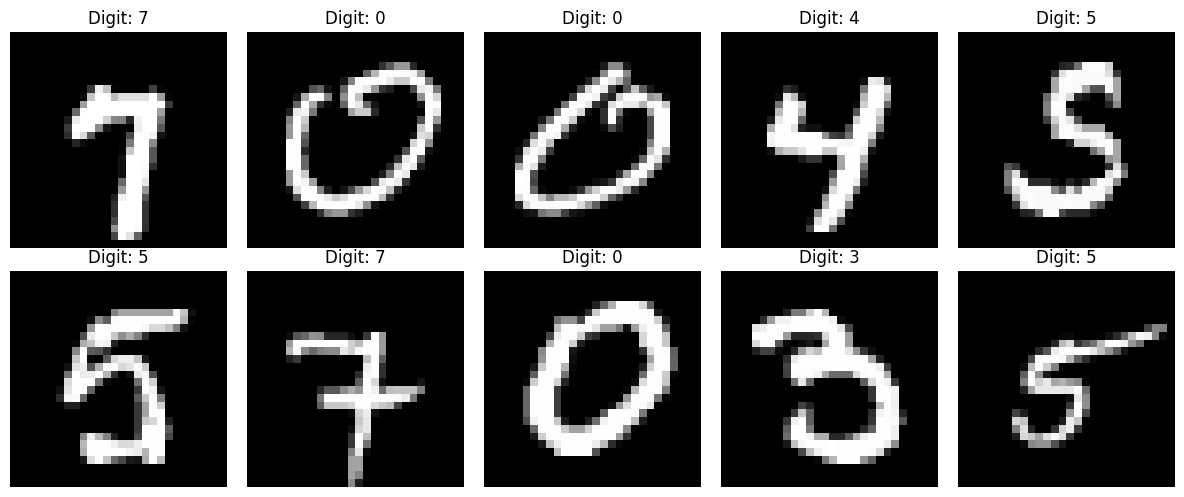

In [6]:
# Get one batch of images and labels from the training dataset
images, labels = next(iter(train_loader))

# Create a figure for displaying images
plt.figure(figsize=(12, 5))

# Display the first 10 images
for i in range(10):

    # Create a subplot
    plt.subplot(2, 5, i + 1)

    # Remove the channel dimension for visualization
    # Image shape changes from (1, 28, 28) to (28, 28)
    plt.imshow(images[i].squeeze(), cmap="gray")

    # Display the actual digit label
    plt.title(f"Digit: {labels[i].item()}")

    # Remove axis values
    plt.axis("off")

# Adjust spacing between images
plt.tight_layout()

# Display the images
plt.show()

**Step 6: Add Artificial Noise**

In [7]:
def add_noise(images, noise_factor=0.5):
    """
    Adds Gaussian noise to input images.

    Parameters:
        images: Original clean images
        noise_factor: Controls the amount of noise

    Returns:
        Noisy images
    """

    # Generate random Gaussian noise
    # The noise has the same shape as the input images
    noise = torch.randn_like(images) * noise_factor

    # Add noise to the original clean images
    noisy_images = images + noise

    # Keep pixel values between 0 and 1
    # This prevents invalid image pixel values
    noisy_images = torch.clamp(noisy_images, 0.0, 1.0)

    return noisy_images

**Step 7: Visualize Clean and Noisy**

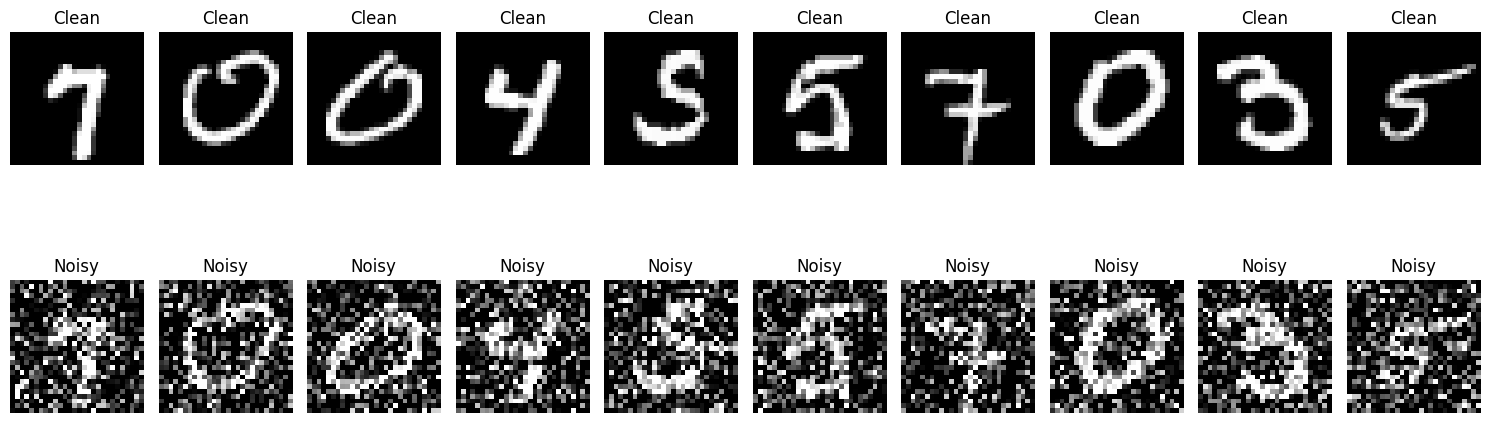

In [8]:
# Create noisy versions of the clean images
noisy_images = add_noise(images)

# Create a figure
plt.figure(figsize=(15, 6))

# Display 10 pairs of clean and noisy images
for i in range(10):

    # Display clean image
    plt.subplot(2, 10, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # Display noisy image
    plt.subplot(2, 10, i + 11)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

# Adjust layout
plt.tight_layout()

# Display the figure
plt.show()

**Observation:**

The noisy images contain random disturbances, but the general shape of the digits is still visible.
This noisy data will be used as the input to the autoencoder.

**Step 8: Build the Denoising Autoencoder**

In [9]:
class DenoisingAutoencoder(nn.Module):

    def __init__(self):

        # Call the constructor of the parent class
        super(DenoisingAutoencoder, self).__init__()

        # ENCODER
        self.encoder = nn.Sequential(

            # First convolutional layer
            # Input: 1 channel grayscale image
            # Output: 32 feature maps
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            # Activation function
            nn.ReLU(),

            # Reduce image size from 28x28 to 14x14
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            ),

            # Second convolutional layer
            # Extract more complex features
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            # Activation function
            nn.ReLU(),

            # Reduce image size from 14x14 to 7x7
            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # DECODER
        self.decoder = nn.Sequential(

            # Upsample from 7x7 to 14x14
            nn.ConvTranspose2d(
                in_channels=64,
                out_channels=32,
                kernel_size=2,
                stride=2
            ),

            # Activation function
            nn.ReLU(),

            # Upsample from 14x14 to 28x28
            nn.ConvTranspose2d(
                in_channels=32,
                out_channels=1,
                kernel_size=2,
                stride=2
            ),

            # Convert output values to range 0-1
            nn.Sigmoid()
        )

    def forward(self, x):

        # Pass input image through encoder
        encoded = self.encoder(x)

        # Reconstruct image using decoder
        decoded = self.decoder(encoded)

        return decoded

**Step 9: Create Model, Loss Function, and Optimizer**

In [10]:
# Create the Denoising Autoencoder model
model = DenoisingAutoencoder()

# Move the model to the selected device
model = model.to(device)

# Mean Squared Error is used for reconstruction loss
criterion = nn.MSELoss()

# Adam optimizer updates the model weights
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Display the model architecture
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


**Step 10: Train the Denoising Autoencoder**

In [11]:
# Define the number of training epochs
num_epochs = 10

# Store loss values for every epoch
train_losses = []

# Start the training process
for epoch in range(num_epochs):

    # Set the model to training mode
    model.train()

    # Store total loss for the current epoch
    running_loss = 0.0

    # Process the training data batch by batch
    for clean_images, _ in train_loader:

        # Move clean images to the selected device
        clean_images = clean_images.to(device)

        # Add artificial noise to clean images
        # These noisy images become the model input
        noisy_images = add_noise(clean_images)

        # Move noisy images to the selected device
        noisy_images = noisy_images.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Pass noisy images through the autoencoder
        denoised_images = model(noisy_images)

        # Compare denoised images with original clean images
        loss = criterion(
            denoised_images,
            clean_images
        )

        # Calculate gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Add current batch loss to total loss
        running_loss += loss.item()

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)

    # Store the loss
    train_losses.append(epoch_loss)

    # Display training progress
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Training Loss: {epoch_loss:.6f}"
    )

Epoch [1/10] Training Loss: 0.035265
Epoch [2/10] Training Loss: 0.016742
Epoch [3/10] Training Loss: 0.015536
Epoch [4/10] Training Loss: 0.014971
Epoch [5/10] Training Loss: 0.014626
Epoch [6/10] Training Loss: 0.014371
Epoch [7/10] Training Loss: 0.014151
Epoch [8/10] Training Loss: 0.013980
Epoch [9/10] Training Loss: 0.013852
Epoch [10/10] Training Loss: 0.013718


**Observation:**

As training progresses, the loss should generally decrease.
A decreasing loss indicates that the model is learning to reconstruct clean images from noisy images.

**Step 11: Plot Training Loss**

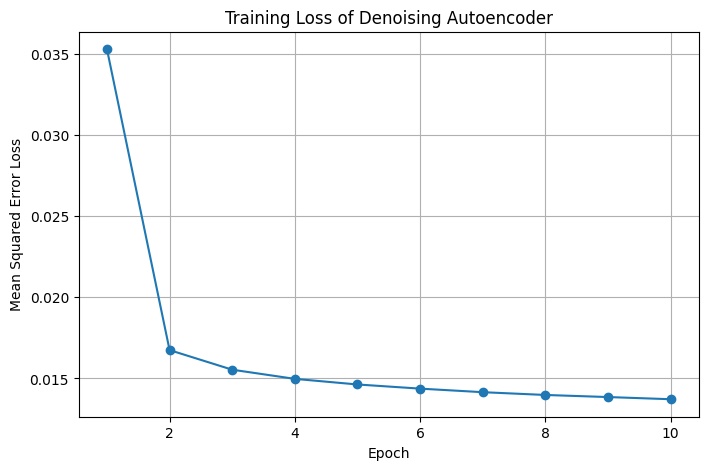

In [12]:
# Create a figure for the training loss graph
plt.figure(figsize=(8, 5))

# Plot loss values for all epochs
plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o"
)

# Add title
plt.title("Training Loss of Denoising Autoencoder")

# Add labels
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")

# Display grid
plt.grid()

# Display the graph
plt.show()

**Observation:**

The training loss decreased consistently from approximately 0.035 in the first epoch to approximately 0.0137 by the tenth epoch. The sharp decrease during the initial epochs indicates that the model quickly learned the basic features of the MNIST digits. After the second epoch, the loss decreased gradually, showing continuous improvement in image reconstruction. The decreasing Mean Squared Error (MSE) indicates that the Denoising Autoencoder successfully learned to reconstruct clean images from noisy input images.

**Step 12: Generate Denoised Outputs on Test Images**

In [13]:
# Set the model to evaluation mode
model.eval()

# Disable gradient calculation during testing
# This saves memory and makes testing faster
with torch.no_grad():

    # Get one batch of clean test images
    test_images, test_labels = next(iter(test_loader))

    # Create noisy versions of test images
    noisy_test_images = add_noise(test_images)

    # Move noisy test images to the selected device
    noisy_test_images = noisy_test_images.to(device)

    # Generate denoised images
    denoised_images = model(noisy_test_images)

    # Move results back to CPU for visualization
    denoised_images = denoised_images.cpu()

print("Denoised test images generated successfully.")

Denoised test images generated successfully.


**Step 13: Compare Clean, Noisy, and Denoised Images**

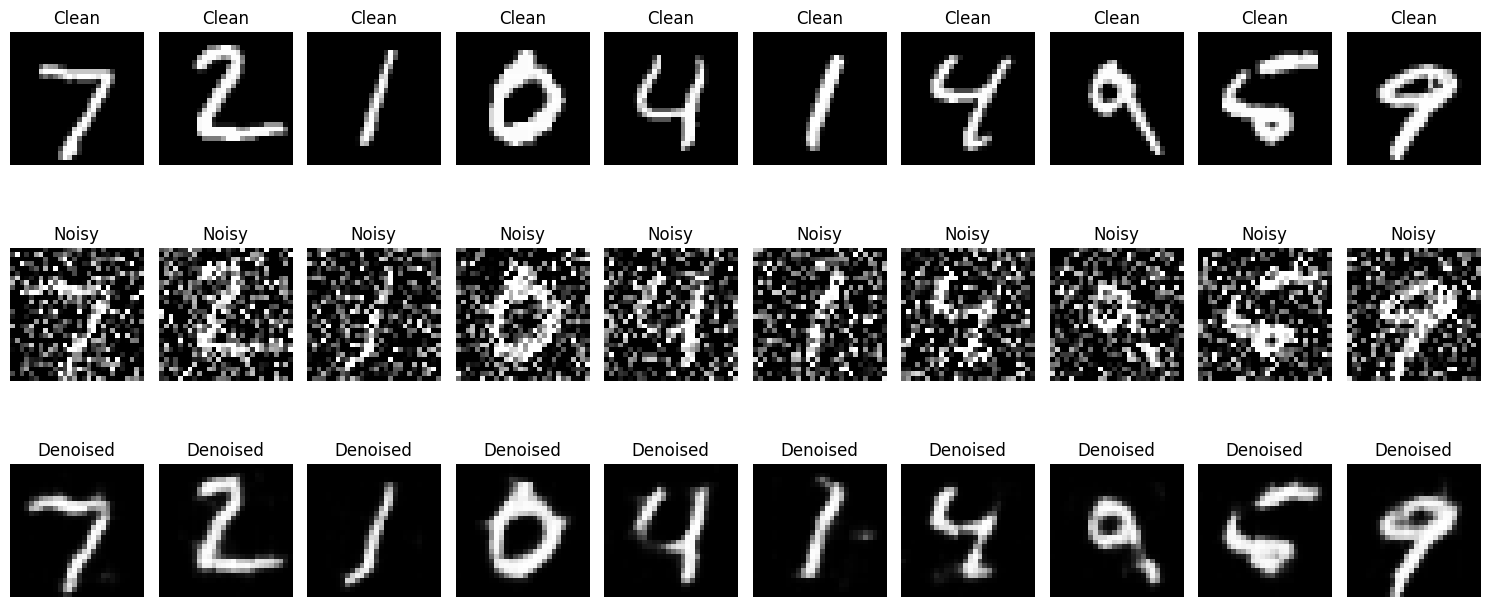

In [14]:
# Create a large figure
plt.figure(figsize=(15, 7))

# Display the first 10 test images
for i in range(10):

    # -------------------------
    # Original Clean Image
    # -------------------------
    plt.subplot(3, 10, i + 1)

    plt.imshow(
        test_images[i].squeeze(),
        cmap="gray"
    )

    plt.title("Clean")
    plt.axis("off")

    # -------------------------
    # Noisy Image
    # -------------------------
    plt.subplot(3, 10, i + 11)

    plt.imshow(
        noisy_test_images[i].cpu().squeeze(),
        cmap="gray"
    )

    plt.title("Noisy")
    plt.axis("off")

    # -------------------------
    # Denoised Image
    # -------------------------
    plt.subplot(3, 10, i + 21)

    plt.imshow(
        denoised_images[i].squeeze(),
        cmap="gray"
    )

    plt.title("Denoised")
    plt.axis("off")

# Adjust spacing
plt.tight_layout()

# Display results
plt.show()

**Observation:**

The visual comparison shows the following:

1. **Clean Images:** The original MNIST digit images are clear and have well-defined shapes.

2. **Noisy Images:** After adding artificial Gaussian noise, the digit images become heavily distorted and contain many random bright and dark pixels. However, the general structure of most digits is still partially visible.

3. **Denoised Images:** The Denoising Autoencoder successfully removes a significant amount of noise from the input images. The reconstructed images are much clearer and visually closer to the original clean images.

4. **Feature Preservation:** The model successfully preserves the important structure and identity of the handwritten digits. For example, digits such as 7, 2, 1, 6, 4, 9, and 5 remain recognizable after denoising.

5. **Slight Blurring:** The denoised images appear slightly blurred compared to the original images. This is expected because the model uses MSE reconstruction loss, which tends to produce smooth reconstructed images

**Step 14: Calculate Test Reconstruction Loss**

In [15]:
# Set the model to evaluation mode
model.eval()

# Variable to store total test loss
test_loss = 0.0

# Disable gradient calculation
with torch.no_grad():

    # Process all test batches
    for clean_images, _ in test_loader:

        # Move clean images to the selected device
        clean_images = clean_images.to(device)

        # Create noisy input images
        noisy_images = add_noise(clean_images)

        # Generate denoised output
        outputs = model(noisy_images)

        # Calculate reconstruction loss
        loss = criterion(
            outputs,
            clean_images
        )

        # Add batch loss
        test_loss += loss.item()

# Calculate average test loss
test_loss = test_loss / len(test_loader)

# Display the final test loss
print(
    f"Test Reconstruction Loss: {test_loss:.6f}"
)

Test Reconstruction Loss: 0.013391


**Observation:**

The Denoising Autoencoder achieved a test reconstruction loss of 0.013391. This low MSE value indicates that the model successfully learned to reconstruct clean MNIST images from noisy inputs. The visual results further show that the denoised images are significantly clearer than the noisy images and preserve the important shapes of the handwritten digits. Therefore, the model performed effectively on the image denoising task.

**Step 15: Save the Trained Model**

In [16]:
# Save the trained model weights
torch.save(
    model.state_dict(),
    "denoising_autoencoder_mnist.pth"
)

print("Model saved successfully.")

Model saved successfully.


## Observations

1. The MNIST dataset was successfully loaded and preprocessed.

2. The images were converted into tensors and normalized to the range 0 to 1.

3. Gaussian noise was added to the clean images to create noisy input images.

4. A convolutional Denoising Autoencoder was built using an encoder and decoder.

5. The encoder compressed the noisy image and extracted important digit features.

6. The decoder reconstructed the image from the extracted features.

7. The model was trained using noisy images as inputs and clean images as target outputs.

8. Mean Squared Error (MSE) was used as the reconstruction loss.

9. The training loss generally decreased with increasing epochs, indicating that the model learned the denoising task.

10. The denoised images were visually clearer than the noisy images and were closer to the original clean images.

11. The performance of the model depends on the amount of noise added. Moderate noise can be removed effectively, while very high noise may make reconstruction more difficult.

12. Overall, the Denoising Autoencoder successfully learned to reduce artificial noise from MNIST handwritten digit images.

## Conclusion

In this assignment, a Denoising Autoencoder was successfully implemented using the MNIST dataset. The dataset was loaded and preprocessed by converting the images into tensors with pixel values normalized between 0 and 1. Artificial Gaussian noise was added to the clean images to generate noisy input data.

A convolutional autoencoder was then built and trained using noisy images as input and clean images as target outputs. Mean Squared Error was used as the reconstruction loss, and the Adam optimizer was used to update the model parameters.

After training, the model was tested on noisy test images. The results showed that the Denoising Autoencoder was able to remove a significant amount of noise and reconstruct images that were visually similar to the original clean MNIST images. The decreasing training loss and visual comparison of clean, noisy, and denoised images demonstrate that the model successfully learned the image denoising task.